# Example of running and analysing the energy system model of the NL

In [274]:
import calliope
import pandas as pd

calliope.set_log_verbosity("INFO", include_solver_output=True)

# 1. Reference case
## 1.1. Create and solve the model

In [275]:
model = calliope.read_yaml('C:\\Users\\amran\\Downloads\\SEN1531_Integrated_Energy_sys\\SEN1531_Integrated_Energy_sys\\calliope_integrated\\model_starter_toolkit\\calliope_model\\model\\model.yaml')


[2026-03-17 11:59:26] INFO     Math init | loading pre-defined math.
[2026-03-17 11:59:26] INFO     Math init | loading math files {'milp', 'storage_inter_cluster', 'spores', 'base', 'operate'}.
[2026-03-17 11:59:26] INFO     Model: preprocessing data
[2026-03-17 11:59:26] INFO     Math build | building applied math with ['base', 'operate'].
[2026-03-17 11:59:26] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-17 11:59:26] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-17 11:59:26] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-17 11:59:26] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-17 11:59:26] INFO     Model: initialisation complete


## check of the capacity factors: Visualized

Reading: C:\Users\amran\Downloads\SEN1531_Integrated_Energy_sys\SEN1531_Integrated_Energy_sys\calliope_integrated\model_starter_toolkit\calliope_model\model\input_data_tables\renewables11.csv
Exists? True
Data shape: (8760, 2)

Column names: ['datetime', 'capacity_factor']
Using datetime column: datetime
Using capacity factor column: capacity_factor


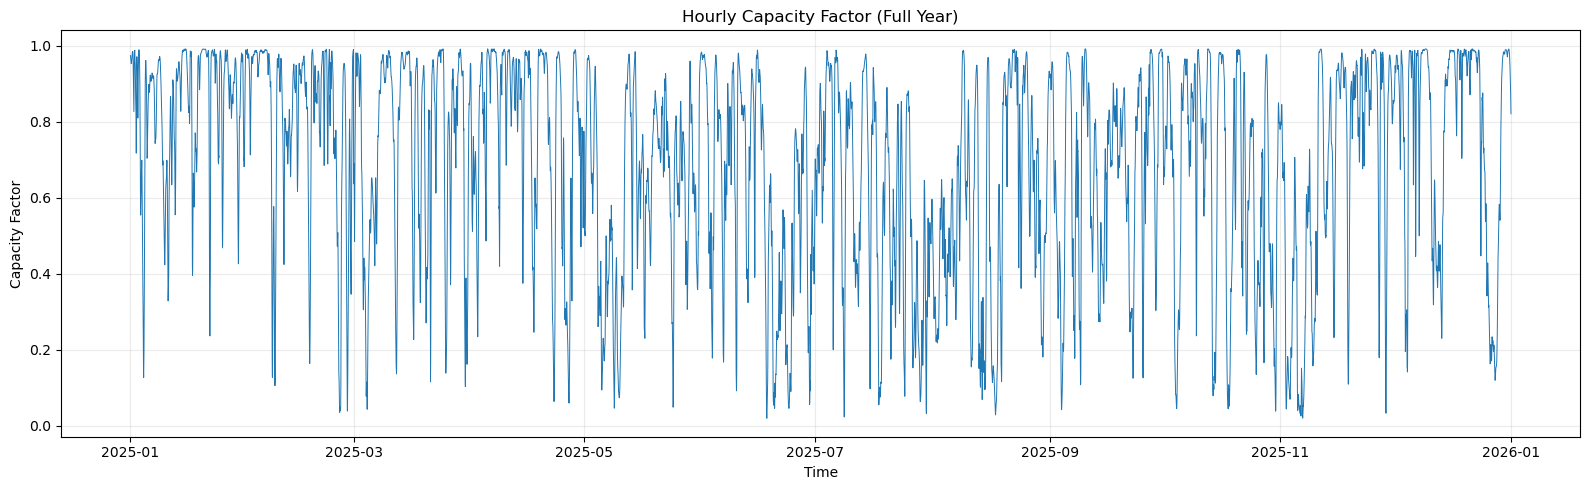

In [276]:
#make a plot of the renewables data against its time steps and the capacity factor for the whole year 
import os
import matplotlib.pyplot as plt
from pathlib import Path

# Ensure we're in the correct model folder so relative paths work
model_dir = Path(r"C:\Users\amran\Downloads\SEN1531_Integrated_Energy_sys\SEN1531_Integrated_Energy_sys\calliope_integrated\model_starter_toolkit\calliope_model")
os.chdir(model_dir)

renewables_path = model_dir / "model" / "input_data_tables" / "renewables11.csv"
print("Reading:", renewables_path)
print("Exists?", renewables_path.exists())

# Load renewables data
renewables_data = pd.read_csv(renewables_path, skiprows=2, names=['datetime', 'capacity_factor'])

# Display data info
print("Data shape:", renewables_data.shape)
print("\nColumn names:", renewables_data.columns.tolist())

# Convert datetime column
renewables_data['datetime'] = pd.to_datetime(renewables_data['datetime'], format='%Y-%m-%d %H:%M:%S')

# Use the capacity_factor column
dt_col = 'datetime'
cf_col = 'capacity_factor'

print(f"Using datetime column: {dt_col}")
print(f"Using capacity factor column: {cf_col}")

# Create the plot: x is datetime over the full year, y is capacity factor
plt.figure(figsize=(16, 5))
plt.plot(renewables_data[dt_col], renewables_data[cf_col], linewidth=0.7)
plt.xlabel('Time')
plt.ylabel('Capacity Factor')
plt.title('Hourly Capacity Factor (Full Year)')
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

In [277]:
# Check the sink_use_equals parameter, it shows the non-empty fixed-demand values used by the model.
model.inputs.sink_use_equals.to_series().dropna()

timesteps            nodes  techs       
2025-01-01 00:00:00  NLD    demand_power   12,567.37
2025-01-01 01:00:00  NLD    demand_power   11,937.46
2025-01-01 02:00:00  NLD    demand_power   11,899.61
2025-01-01 03:00:00  NLD    demand_power   11,692.96
2025-01-01 04:00:00  NLD    demand_power   11,338.91
                                              ...   
2025-03-31 19:00:00  NLD    demand_power   13,162.69
2025-03-31 20:00:00  NLD    demand_power   12,410.78
2025-03-31 21:00:00  NLD    demand_power   10,712.50
2025-03-31 22:00:00  NLD    demand_power    9,444.83
2025-03-31 23:00:00  NLD    demand_power    9,462.67
Name: sink_use_equals, Length: 2160, dtype: float64

In [278]:
import os, calliope
os.chdir(r"C:\Users\amran\Downloads\SEN1531_Integrated_Energy_sys\SEN1531_Integrated_Energy_sys\calliope_integrated\model_starter_toolkit\calliope_model")
model = calliope.read_yaml("model/model.yaml")
model.build()
model.solve()


print(model.results.attrs.get("termination_condition"))  # should be optimal/feasible
model.to_netcdf("results/default_results.nc")


[2026-03-17 11:59:27] INFO     Math init | loading pre-defined math.
[2026-03-17 11:59:27] INFO     Math init | loading math files {'milp', 'storage_inter_cluster', 'spores', 'base', 'operate'}.


[2026-03-17 11:59:27] INFO     Model: preprocessing data
[2026-03-17 11:59:27] INFO     Math build | building applied math with ['base', 'operate'].
[2026-03-17 11:59:27] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-17 11:59:27] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-17 11:59:27] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-17 11:59:27] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-17 11:59:28] INFO     Model: initialisation complete
[2026-03-17 11:59:28] INFO     Model: backend build starting
[2026-03-17 11:59:28] INFO     Optimisation Model | parameters/lookups | Generated.
[2026-03-17 11:59:28] INFO     Optimisation Model | variables | Generated.
[2026-03-17 11:59:30] INFO     Optimisation Mod

## 1.2. Do a first sense-check of the results

In [279]:
# Shadow price for the power system balance constraint
balance_price = model.backend.shadow_prices.get("system_balance").to_series().reset_index()
balance_price.head()

,nodes,carriers,timesteps,system_balance
0,NLD,hydrogen,2025-01-01 00:00:00,-0.00
1,NLD,hydrogen,2025-01-01 01:00:00,-0.00
2,NLD,hydrogen,2025-01-01 02:00:00,-0.00
3,NLD,hydrogen,2025-01-01 03:00:00,-0.00
4,NLD,hydrogen,2025-01-01 04:00:00,-0.00


<Axes: >

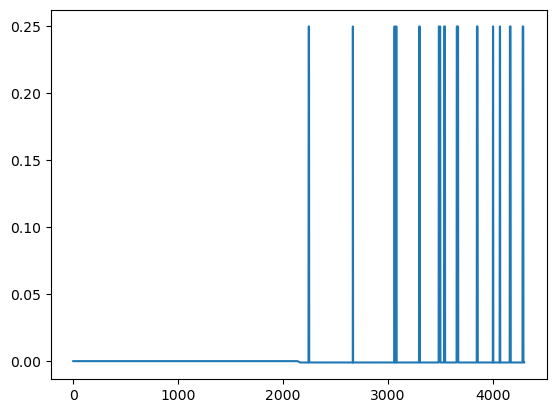

In [280]:
# Create a Date Range to select a few days in November to inspect visually
days_of_interest = pd.date_range('2025-01-01','2025-03-31',freq='h') 
# Plot the days of interest
balance_price['system_balance'].loc[balance_price['timesteps'].isin(days_of_interest)].plot()

In [281]:
variable_costs = model.results.cost_operation_variable.to_series().dropna()
variable_costs.head()

nodes  techs            costs     timesteps          
NLD    battery_storage  monetary  2025-01-01 00:00:00   0.00
                                  2025-01-01 01:00:00   0.00
                                  2025-01-01 02:00:00   0.00
                                  2025-01-01 03:00:00   0.00
                                  2025-01-01 04:00:00   0.00
Name: cost_operation_variable, dtype: float64

In [282]:
generation = model.results.flow_out.to_series().dropna()
generation.head()

nodes  techs            carriers  timesteps          
NLD    battery_storage  power     2025-01-01 00:00:00   0.00
                                  2025-01-01 01:00:00   0.00
                                  2025-01-01 02:00:00   0.00
                                  2025-01-01 03:00:00   0.00
                                  2025-01-01 04:00:00   0.00
Name: flow_out, dtype: float64

In [283]:
# If we calculate the marginal generation costs per generator type,
# we should see an equivalence between the shadow price in any given
# hour and the marginal cost of the marginal generator in the merit order
marginal_generation_costs = variable_costs/generation
marginal_generation_costs.head()

nodes  techs            costs     timesteps            carriers
NLD    battery_storage  monetary  2025-01-01 00:00:00  power      NaN
                                  2025-01-01 01:00:00  power      NaN
                                  2025-01-01 02:00:00  power      NaN
                                  2025-01-01 03:00:00  power      NaN
                                  2025-01-01 04:00:00  power      NaN
dtype: float64

In [284]:
# To check the merit order, we may look at a particular timestep
# and at the list of generators producing in that timestep in ascending cost order.
# The per-timestep selection is easier done before transforming to a Pandas series.
marginal_generation_costs_xr = model.results.cost_operation_variable / model.results.flow_out
# We select a specific hour of the year
my_timestep = '2025-01-02 04:00:00'
# And we select only generators, excluding curtailment and other techs
gen_techs = ['wind_offshore']
# gen_techs = ['solar_pv' ,'wind_offshore', 'wind_onshore', 'ccgt', 'nuclear'] 
# We can now inspect the marginal generation cost in that timestep
marginal_generation_cost_in_timestep = marginal_generation_costs_xr.sel(timesteps=my_timestep, carriers='power', costs='monetary', techs=gen_techs)
marginal_generation_cost_in_timestep.to_series().fillna(0).sort_values()

nodes  techs        
NLD    wind_offshore   0.00
dtype: float64

## 1.3. Export the results for further analysis at any later moment

In [285]:
# It is helpful to store the model results as a whole in NetCDF format, which Calliope can import back
# at any later time. 
model.to_netcdf('results/default_results.nc')


## 1.4. Produce some visualisations

In this example, we provide some pre-made plotting functionalities in the 'plotting_utilities.py' file, which you can import and apply as well as use as an example for making your own custom plots.

In [286]:
# Import some pre-made plotting functionalities as an example. You can use these, make your own, or simply
# create plots with your favourite Python library or non-Python tool, such as Excel
from plotting_utilities import plot_dispatch,plot_load_duration_curve

In [287]:
# Dispatch plots can be generated directly from the saved model results
plot_dispatch(model_path='results/default_results.nc', plot_export_path='results/default_dispatch.html')

[2026-03-17 11:59:38] INFO     Model: preprocessing data (reentry)
[2026-03-17 11:59:38] INFO     Math build | building applied math with ['base', 'operate'].
[2026-03-17 11:59:38] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-17 11:59:38] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-17 11:59:39] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-17 11:59:39] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-17 11:59:39] INFO     Model: initialisation complete


In [288]:
# For generating load duration curves (LDCs), instead, we first need to import back the model results,
# then extract the time-varing variable of interest
model = calliope.read_netcdf('results/default_results.nc')

[2026-03-17 11:59:39] INFO     Model: preprocessing data (reentry)
[2026-03-17 11:59:39] INFO     Math build | building applied math with ['base', 'operate'].
[2026-03-17 11:59:39] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-17 11:59:39] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-17 11:59:39] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-17 11:59:39] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-17 11:59:39] INFO     Model: initialisation complete


In [289]:
import pandas as pd

print("Termination:", model.results.attrs.get("termination_condition"))

# Energy totals (MWh over model horizon)
demand_served = model.results.flow_in.sel(techs="demand_power", carriers="power").sum().item()
curtailed = model.results.flow_in.sel(techs="curtailment", carriers="power").sum().item()
load_shed = model.results.flow_out.sel(techs="load_shedding", carriers="power").sum().item()
wind_gen = model.results.flow_out.sel(techs="wind_offshore", carriers="power").sum().item()

# Available wind energy from profile * installed cap
wind_avail = (
    model.inputs.source_use_equals.sel(techs="wind_offshore", nodes="NLD")
    * model.inputs.flow_cap.sel(techs="wind_offshore", nodes="NLD")
).sum().item()

curtailment_rate = (curtailed / wind_avail * 100) if wind_avail > 0 else 0

# Shadow price stats


sp = model.results.shadow_price_system_balance.to_series()
price_stats = sp.describe(percentiles=[0.5, 0.95])[["mean", "50%", "95%", "max"]]

kpis = pd.Series({
    "Demand served (MWh)": demand_served,
    "Wind available (MWh)": wind_avail,
    "Wind generated (MWh)": wind_gen,
    "Curtailment (MWh)": curtailed,
    "Curtailment rate (%)": curtailment_rate,
    "Load shedding (MWh)": load_shed,
})

print(kpis)
print("\nSystem balance price stats:")
print(price_stats)



Termination: None
Demand served (MWh)     34,492,087.41
Wind available (MWh)   119,655,823.00
Wind generated (MWh)   119,655,823.00
Curtailment (MWh)       85,925,210.71
Curtailment rate (%)            71.81
Load shedding (MWh)        761,475.12
dtype: float64

System balance price stats:
mean   0.00
50%    0.00
95%    0.00
max    0.25
Name: shadow_price_system_balance, dtype: float64


## 2. Battery Scenario

Run only the battery pathway scenario and extract baseline + battery-specific KPIs.

In [290]:
scenario_name = "surplus_to_battery"
model_battery = calliope.read_yaml("model/model.yaml", scenario=scenario_name)
model_battery.build()
model_battery.solve()
print("Termination:", model_battery.results.attrs.get("termination_condition"))
model_battery.to_netcdf(f"results/{scenario_name}_results.nc")


[2026-03-17 11:59:40] INFO     Loading overrides from scenario: surplus_to_battery 
[2026-03-17 11:59:40] INFO     (scenarios, surplus_to_battery ) | Applying the following overrides: ['enable_battery_pathway'].
[2026-03-17 11:59:40] INFO     Math init | loading pre-defined math.
[2026-03-17 11:59:40] INFO     Math init | loading math files {'milp', 'storage_inter_cluster', 'spores', 'base', 'operate'}.
[2026-03-17 11:59:40] INFO     Model: preprocessing data
[2026-03-17 11:59:40] INFO     Math build | building applied math with ['base', 'operate'].
[2026-03-17 11:59:40] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-17 11:59:40] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-17 11:59:40] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-17 11:59:40] INFO     input data `name` not

In [291]:
plot_dispatch(
    model_path=f"results/{scenario_name}_results.nc",
    plot_export_path=f"results/{scenario_name}_dispatch.html",
)


[2026-03-17 11:59:51] INFO     Model: preprocessing data (reentry)
[2026-03-17 11:59:51] INFO     Math build | building applied math with ['base', 'operate'].
[2026-03-17 11:59:51] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-17 11:59:51] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-17 11:59:51] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-17 11:59:51] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-17 11:59:51] INFO     Model: initialisation complete


In [292]:
import pandas as pd

m = calliope.read_netcdf(f"results/{scenario_name}_results.nc")

# Common KPIs
demand_served = m.results.flow_in.sel(techs="demand_power", carriers="power").sum().item()
curtailed = m.results.flow_in.sel(techs="curtailment", carriers="power").sum().item()
load_shed = m.results.flow_out.sel(techs="load_shedding", carriers="power").sum().item()
wind_gen = m.results.flow_out.sel(techs="wind_offshore", carriers="power").sum().item()

if "source_use_equals" in m.inputs.data_vars:
    wind_avail = (
        m.inputs.source_use_equals.sel(techs="wind_offshore", nodes="NLD")
        * m.inputs.flow_cap.sel(techs="wind_offshore", nodes="NLD")
    ).sum().item()
else:
    wind_avail = (
        m.inputs.source_use_max.sel(techs="wind_offshore", nodes="NLD")
        * m.inputs.flow_cap.sel(techs="wind_offshore", nodes="NLD")
    ).sum().item()

curtailment_rate = (curtailed / wind_avail * 100) if wind_avail > 0 else 0
sp = m.results.shadow_price_system_balance.sel(nodes="NLD", carriers="power").to_series().dropna()
price_stats = sp.describe(percentiles=[0.5, 0.95])[["mean", "50%", "95%", "max"]]
pd.set_option("display.float_format", "{:,.2f}".format)

# Battery-specific KPIs
battery_charge = m.results.flow_in.sel(techs="battery_storage", carriers="power").sum().item()
battery_discharge = m.results.flow_out.sel(techs="battery_storage", carriers="power").sum().item()
battery_losses = battery_charge - battery_discharge
battery_round_trip = (battery_discharge / battery_charge * 100) if battery_charge > 0 else 0

kpis_battery = pd.Series({
    "Demand served (MWh)": demand_served,
    "Wind available (MWh)": wind_avail,
    "Wind generated (MWh)": wind_gen,
    "Curtailment (MWh)": curtailed,
    "Curtailment rate (%)": curtailment_rate,
    "Load shedding (MWh)": load_shed,
    "Battery charge (MWh)": battery_charge,
    "Battery discharge (MWh)": battery_discharge,
    "Battery losses (MWh)": battery_losses,
    "Battery round-trip (%)": battery_round_trip,
})

print(kpis_battery)
print("\nPower system balance price stats:")
print(price_stats)


[2026-03-17 11:59:52] INFO     Model: preprocessing data (reentry)
[2026-03-17 11:59:52] INFO     Math build | building applied math with ['base', 'operate'].
[2026-03-17 11:59:52] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-17 11:59:52] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-17 11:59:52] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-17 11:59:52] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-17 11:59:52] INFO     Model: initialisation complete
Demand served (MWh)        34,492,087.41
Wind available (MWh)      119,655,823.00
Wind generated (MWh)      119,655,823.00
Curtailment (MWh)          85,767,527.56
Curtailment rate (%)               71.68
Load shedding (MWh)           707,096.23
Battery cha

## 3. Hydrogen Scenario

Run the hydrogen pathway scenario, export results, and compute hydrogen-specific KPIs.

In [293]:
scenario_name_h2 = "surplus_to_hydrogen"
model_h2 = calliope.read_yaml("model/model.yaml", scenario=scenario_name_h2)
model_h2.build()
model_h2.solve()
print("Termination:", model_h2.results.attrs.get("termination_condition"))
model_h2.to_netcdf(f"results/{scenario_name_h2}_results.nc")


[2026-03-17 11:59:52] INFO     Loading overrides from scenario: surplus_to_hydrogen 
[2026-03-17 11:59:52] INFO     (scenarios, surplus_to_hydrogen ) | Applying the following overrides: ['enable_hydrogen_pathway'].


[2026-03-17 11:59:52] INFO     Math init | loading pre-defined math.
[2026-03-17 11:59:52] INFO     Math init | loading math files {'milp', 'storage_inter_cluster', 'spores', 'base', 'operate'}.
[2026-03-17 11:59:52] INFO     Model: preprocessing data
[2026-03-17 11:59:52] INFO     Math build | building applied math with ['base', 'operate'].
[2026-03-17 11:59:53] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-17 11:59:53] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-17 11:59:53] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-17 11:59:53] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-17 11:59:53] INFO     Model: initialisation complete
[2026-03-17 11:59:53] INFO     Model: backend build starting
[2026-03-17

In [294]:
plot_dispatch(
    model_path=f"results/{scenario_name_h2}_results.nc",
    plot_export_path=f"results/{scenario_name_h2}_dispatch.html",
)


[2026-03-17 12:00:03] INFO     Model: preprocessing data (reentry)
[2026-03-17 12:00:03] INFO     Math build | building applied math with ['base', 'operate'].
[2026-03-17 12:00:03] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-17 12:00:03] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-17 12:00:03] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-17 12:00:03] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-17 12:00:03] INFO     Model: initialisation complete


In [295]:
m_h2 = calliope.read_netcdf(f"results/{scenario_name_h2}_results.nc")

demand_served_h2 = m_h2.results.flow_in.sel(techs="demand_power", carriers="power").sum().item()
curtailed_h2 = m_h2.results.flow_in.sel(techs="curtailment", carriers="power").sum().item()
load_shed_h2 = m_h2.results.flow_out.sel(techs="load_shedding", carriers="power").sum().item()
wind_gen_h2 = m_h2.results.flow_out.sel(techs="wind_offshore", carriers="power").sum().item()

if "source_use_equals" in m_h2.inputs.data_vars:
    wind_avail_h2 = (m_h2.inputs.source_use_equals.sel(techs="wind_offshore", nodes="NLD") * m_h2.inputs.flow_cap.sel(techs="wind_offshore", nodes="NLD")).sum().item()
else:
    wind_avail_h2 = (m_h2.inputs.source_use_max.sel(techs="wind_offshore", nodes="NLD") * m_h2.inputs.flow_cap.sel(techs="wind_offshore", nodes="NLD")).sum().item()

curtailment_rate_h2 = (curtailed_h2 / wind_avail_h2 * 100) if wind_avail_h2 > 0 else 0
sp_h2 = m_h2.results.shadow_price_system_balance.sel(nodes="NLD", carriers="power").to_series().dropna()
price_stats_h2 = sp_h2.describe(percentiles=[0.5, 0.95])[["mean", "50%", "95%", "max"]]

electrolyser_in = m_h2.results.flow_in.sel(techs="electrolyser", carriers="power").sum().item()
fuel_cell_out = m_h2.results.flow_out.sel(techs="fuel_cell", carriers="power").sum().item() if "fuel_cell" in m_h2.results.coords["techs"].values else 0.0
h2_storage_in = m_h2.results.flow_in.sel(techs="hydrogen_storage", carriers="hydrogen").sum().item()
h2_storage_out = m_h2.results.flow_out.sel(techs="hydrogen_storage", carriers="hydrogen").sum().item()
h2_round_trip = (fuel_cell_out / electrolyser_in * 100) if electrolyser_in > 0 else 0

kpis_hydrogen = pd.Series({
    "Demand served (MWh)": demand_served_h2,
    "Wind available (MWh)": wind_avail_h2,
    "Wind generated (MWh)": wind_gen_h2,
    "Curtailment (MWh)": curtailed_h2,
    "Curtailment rate (%)": curtailment_rate_h2,
    "Load shedding (MWh)": load_shed_h2,
    "Electrolyser input (MWh)": electrolyser_in,
    "Fuel cell output (MWh)": fuel_cell_out,
    "H2 storage charge (MWh_H2)": h2_storage_in,
    "H2 storage discharge (MWh_H2)": h2_storage_out,
    "Power-to-power via H2 (%)": h2_round_trip,
})

print(kpis_hydrogen)
print("\nPower system balance price stats:")
print(price_stats_h2)


[2026-03-17 12:00:04] INFO     Model: preprocessing data (reentry)
[2026-03-17 12:00:04] INFO     Math build | building applied math with ['base', 'operate'].
[2026-03-17 12:00:04] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-17 12:00:04] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-17 12:00:04] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-17 12:00:04] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-17 12:00:04] INFO     Model: initialisation complete
Demand served (MWh)              34,492,087.41
Wind available (MWh)            119,655,823.00
Wind generated (MWh)            119,655,823.00
Curtailment (MWh)                85,902,713.58
Curtailment rate (%)                     71.79
Load shedding (MWh)   

## 4. Big User Scenario

Run the flexible large-user pathway scenario and compute user-specific KPIs.

In [296]:
scenario_name_user = "surplus_to_big_user"
model_user = calliope.read_yaml("model/model.yaml", scenario=scenario_name_user)
model_user.build()
model_user.solve()
print("Termination:", model_user.results.attrs.get("termination_condition"))
model_user.to_netcdf(f"results/{scenario_name_user}_results.nc")


[2026-03-17 12:00:04] INFO     Loading overrides from scenario: surplus_to_big_user 
[2026-03-17 12:00:04] INFO     (scenarios, surplus_to_big_user ) | Applying the following overrides: ['enable_big_user_pathway'].
[2026-03-17 12:00:04] INFO     Math init | loading pre-defined math.
[2026-03-17 12:00:04] INFO     Math init | loading math files {'milp', 'storage_inter_cluster', 'spores', 'base', 'operate'}.
[2026-03-17 12:00:04] INFO     Model: preprocessing data
[2026-03-17 12:00:04] INFO     Math build | building applied math with ['base', 'operate'].
[2026-03-17 12:00:05] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-17 12:00:05] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-17 12:00:05] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-17 12:00:05] INFO     input data `name` 

In [297]:
plot_dispatch(
    model_path=f"results/{scenario_name_user}_results.nc",
    plot_export_path=f"results/{scenario_name_user}_dispatch.html",
)


[2026-03-17 12:00:16] INFO     Model: preprocessing data (reentry)
[2026-03-17 12:00:16] INFO     Math build | building applied math with ['base', 'operate'].
[2026-03-17 12:00:16] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-17 12:00:16] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-17 12:00:16] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-17 12:00:16] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-17 12:00:16] INFO     Model: initialisation complete


In [298]:
m_user = calliope.read_netcdf(f"results/{scenario_name_user}_results.nc")

demand_served_user = m_user.results.flow_in.sel(techs="demand_power", carriers="power").sum().item()
curtailed_user = m_user.results.flow_in.sel(techs="curtailment", carriers="power").sum().item()
load_shed_user = m_user.results.flow_out.sel(techs="load_shedding", carriers="power").sum().item()
wind_gen_user = m_user.results.flow_out.sel(techs="wind_offshore", carriers="power").sum().item()

if "source_use_equals" in m_user.inputs.data_vars:
    wind_avail_user = (m_user.inputs.source_use_equals.sel(techs="wind_offshore", nodes="NLD") * m_user.inputs.flow_cap.sel(techs="wind_offshore", nodes="NLD")).sum().item()
else:
    wind_avail_user = (m_user.inputs.source_use_max.sel(techs="wind_offshore", nodes="NLD") * m_user.inputs.flow_cap.sel(techs="wind_offshore", nodes="NLD")).sum().item()

curtailment_rate_user = (curtailed_user / wind_avail_user * 100) if wind_avail_user > 0 else 0
sp_user = m_user.results.shadow_price_system_balance.sel(nodes="NLD", carriers="power").to_series().dropna()
price_stats_user = sp_user.describe(percentiles=[0.5, 0.95])[["mean", "50%", "95%", "max"]]

big_user_energy = m_user.results.flow_in.sel(techs="demand_big_user", carriers="power").sum().item()
big_user_avg_mw = big_user_energy / 8760
big_user_revenue_kEUR = big_user_energy * 0.02

kpis_big_user = pd.Series({
    "Demand served (MWh)": demand_served_user,
    "Wind available (MWh)": wind_avail_user,
    "Wind generated (MWh)": wind_gen_user,
    "Curtailment (MWh)": curtailed_user,
    "Curtailment rate (%)": curtailment_rate_user,
    "Load shedding (MWh)": load_shed_user,
    "Big user served (MWh)": big_user_energy,
    "Big user avg load (MW)": big_user_avg_mw,
    "Big user revenue equivalent (kEUR)": big_user_revenue_kEUR,
})

print(kpis_big_user)
print("\nPower system balance price stats:")
print(price_stats_user)


[2026-03-17 12:00:16] INFO     Model: preprocessing data (reentry)
[2026-03-17 12:00:16] INFO     Math build | building applied math with ['base', 'operate'].
[2026-03-17 12:00:16] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-17 12:00:16] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-17 12:00:16] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-17 12:00:16] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-17 12:00:17] INFO     Model: initialisation complete
Demand served (MWh)                   34,492,087.41
Wind available (MWh)                 119,655,823.00
Wind generated (MWh)                 119,655,823.00
Curtailment (MWh)                     80,770,430.05
Curtailment rate (%)                          67.

## 5. Compare The Three Scenarios

Build one comparison table from saved NetCDF results.

In [299]:
import numpy as np
import pandas as pd
from pathlib import Path

def _wind_available(model):
    if "source_use_equals" in model.inputs.data_vars:
        profile = model.inputs.source_use_equals.sel(techs="wind_offshore", nodes="NLD")
    else:
        profile = model.inputs.source_use_max.sel(techs="wind_offshore", nodes="NLD")
    cap = model.inputs.flow_cap.sel(techs="wind_offshore", nodes="NLD")
    return (profile * cap).sum().item()

def compute_kpis(nc_path, scenario_type):
    m = calliope.read_netcdf(nc_path)
    demand_served = m.results.flow_in.sel(techs="demand_power", carriers="power").sum().item()
    curtailed = m.results.flow_in.sel(techs="curtailment", carriers="power").sum().item()
    load_shed = m.results.flow_out.sel(techs="load_shedding", carriers="power").sum().item()
    wind_gen = m.results.flow_out.sel(techs="wind_offshore", carriers="power").sum().item()
    wind_avail = _wind_available(m)
    curtailment_rate = (curtailed / wind_avail * 100) if wind_avail > 0 else 0

    if "shadow_price_system_balance" in m.results.data_vars:
        sp = m.results.shadow_price_system_balance.sel(nodes="NLD", carriers="power").to_series().dropna()
        price_mean = sp.mean() if len(sp) else np.nan
        price_p95 = sp.quantile(0.95) if len(sp) else np.nan
        price_max = sp.max() if len(sp) else np.nan
    else:
        price_mean, price_p95, price_max = np.nan, np.nan, np.nan

    out = {
        "Demand served (MWh)": demand_served,
        "Wind available (MWh)": wind_avail,
        "Wind generated (MWh)": wind_gen,
        "Curtailment (MWh)": curtailed,
        "Curtailment rate (%)": curtailment_rate,
        "Load shedding (MWh)": load_shed,
        "Price mean (kEUR/MWh)": price_mean,
        "Price p95 (kEUR/MWh)": price_p95,
        "Price max (kEUR/MWh)": price_max,
    }

    if scenario_type == "battery":
        ch = m.results.flow_in.sel(techs="battery_storage", carriers="power").sum().item()
        dis = m.results.flow_out.sel(techs="battery_storage", carriers="power").sum().item()
        out["Battery discharge (MWh)"] = dis
        out["Battery round-trip (%)"] = (dis / ch * 100) if ch > 0 else np.nan
    elif scenario_type == "hydrogen":
        el = m.results.flow_in.sel(techs="electrolyser", carriers="power").sum().item()
        fc = m.results.flow_out.sel(techs="fuel_cell", carriers="power").sum().item() if "fuel_cell" in m.results.coords["techs"].values else 0.0
        out["Electrolyser input (MWh)"] = el
        out["Fuel cell output (MWh)"] = fc
        out["Power-to-power via H2 (%)"] = (fc / el * 100) if el > 0 else np.nan
    elif scenario_type == "big_user":
        bu = m.results.flow_in.sel(techs="demand_big_user", carriers="power").sum().item()
        out["Big user served (MWh)"] = bu
        out["Big user revenue equivalent (kEUR)"] = bu * 0.02

    return out

scenario_meta = {
    "surplus_to_battery": "battery",
    "surplus_to_hydrogen": "hydrogen",
    "surplus_to_big_user": "big_user",
}

rows = {}
for sc, kind in scenario_meta.items():
    nc = Path("results") / f"{sc}_results.nc"
    if not nc.exists():
        print(f"Skipping {sc}: {nc} not found. Run that scenario cell first.")
        continue
    rows[sc] = compute_kpis(str(nc), kind)

if not rows:
    raise RuntimeError("No scenario result files found. Run scenario solve cells first.")

kpi_compare = pd.DataFrame(rows).T
kpi_compare


[2026-03-17 12:00:17] INFO     Model: preprocessing data (reentry)
[2026-03-17 12:00:17] INFO     Math build | building applied math with ['base', 'operate'].
[2026-03-17 12:00:17] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-17 12:00:17] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-17 12:00:17] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-17 12:00:17] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-17 12:00:17] INFO     Model: initialisation complete
[2026-03-17 12:00:17] INFO     Model: preprocessing data (reentry)
[2026-03-17 12:00:17] INFO     Math build | building applied math with ['base', 'operate'].
[2026-03-17 12:00:17] INFO     input data `color` not defined in model math; it will not be availa

,Demand served (MWh),Wind available (MWh),Wind generated (MWh),Curtailment (MWh),Curtailment rate (%),Load shedding (MWh),Price mean (kEUR/MWh),Price p95 (kEUR/MWh),Price max (kEUR/MWh),Battery discharge (MWh),Battery round-trip (%),Electrolyser input (MWh),Fuel cell output (MWh),Power-to-power via H2 (%),Big user served (MWh),Big user revenue equivalent (kEUR)
surplus_to_battery,"34,492,087.41","119,655,823.00","119,655,823.00","85,767,527.56",71.68,"707,096.23",0.01,-0.00,0.25,"2,382,683.30",95.84,NaN,NaN,NaN,NaN,NaN
surplus_to_hydrogen,"34,492,087.41","119,655,823.00","119,655,823.00","85,902,713.58",71.79,"761,475.12",0.01,-0.00,0.25,NaN,NaN,"22,497.13",0.00,0.00,NaN,NaN
surplus_to_big_user,"34,492,087.41","119,655,823.00","119,655,823.00","80,770,430.05",67.50,"761,475.16",0.01,-0.00,0.25,NaN,NaN,NaN,NaN,NaN,"5,154,780.69","103,095.61"


## 6. Extra Diagnostics (Non-Redundant)

These metrics complement `kpi_compare` with hour-based reliability indicators and utilization checks.

In [300]:
import numpy as np
import pandas as pd
from pathlib import Path

# Reuse scenario_meta from above if available
try:
    scenario_meta
except NameError:
    scenario_meta = {
        "surplus_to_battery": "battery",
        "surplus_to_hydrogen": "hydrogen",
        "surplus_to_big_user": "big_user",
    }

diag_rows = {}
for sc, kind in scenario_meta.items():
    nc = Path("results") / f"{sc}_results.nc"
    if not nc.exists():
        continue

    m = calliope.read_netcdf(str(nc))
    ts_curt = m.results.flow_in.sel(techs="curtailment", carriers="power").to_series().fillna(0)
    ts_shed = m.results.flow_out.sel(techs="load_shedding", carriers="power").to_series().fillna(0)

    if "shadow_price_system_balance" in m.results.data_vars:
        ts_price = m.results.shadow_price_system_balance.sel(nodes="NLD", carriers="power").to_series().dropna()
    else:
        ts_price = pd.Series(dtype=float)

    row = {
        "Curtailment hours (>0 MW)": int((ts_curt > 1e-6).sum()),
        "Load shedding hours (>0 MW)": int((ts_shed > 1e-6).sum()),
        "Peak curtailment (MW)": float(ts_curt.max()) if len(ts_curt) else np.nan,
        "Peak load shedding (MW)": float(ts_shed.max()) if len(ts_shed) else np.nan,
        "Scarcity price hours (>=0.249)": int((ts_price >= 0.249).sum()) if len(ts_price) else np.nan,
    }

    if kind == "battery":
        dis = m.results.flow_out.sel(techs="battery_storage", carriers="power").sum().item()
        try:
            e_cap = float(m.inputs.storage_cap.sel(nodes="NLD", techs="battery_storage").item())
        except Exception:
            e_cap = np.nan
        row["Battery equivalent full cycles"] = dis / e_cap if e_cap and e_cap > 0 else np.nan

    if kind == "hydrogen":
        el_in = m.results.flow_in.sel(techs="electrolyser", carriers="power").to_series().fillna(0)
        try:
            p_cap = float(m.inputs.flow_cap.sel(nodes="NLD", techs="electrolyser").item())
        except Exception:
            p_cap = np.nan
        row["Electrolyser utilization (%)"] = 100 * el_in.mean() / p_cap if p_cap and p_cap > 0 else np.nan

    if kind == "big_user":
        bu = m.results.flow_in.sel(techs="demand_big_user", carriers="power").to_series().fillna(0)
        try:
            bu_max = float(m.inputs.sink_use_max.sel(techs="demand_big_user").item())
        except Exception:
            bu_max = np.nan
        row["Big user utilization (%)"] = 100 * bu.mean() / bu_max if bu_max and bu_max > 0 else np.nan

    diag_rows[sc] = row

diag_compare = pd.DataFrame(diag_rows).T
diag_compare


[2026-03-17 12:00:19] INFO     Model: preprocessing data (reentry)
[2026-03-17 12:00:19] INFO     Math build | building applied math with ['base', 'operate'].
[2026-03-17 12:00:19] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-17 12:00:19] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-17 12:00:19] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-17 12:00:19] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-17 12:00:19] INFO     Model: initialisation complete
[2026-03-17 12:00:19] INFO     Model: preprocessing data (reentry)
[2026-03-17 12:00:19] INFO     Math build | building applied math with ['base', 'operate'].
[2026-03-17 12:00:19] INFO     input data `color` not defined in model math; it will not be availa

,Curtailment hours (>0 MW),Load shedding hours (>0 MW),Peak curtailment (MW),Peak load shedding (MW),Scarcity price hours (>=0.249),Battery equivalent full cycles,Electrolyser utilization (%),Big user utilization (%)
surplus_to_battery,"2,073.00",87.00,"61,855.02","16,703.68",87.00,484.29,NaN,NaN
surplus_to_hydrogen,"2,069.00",91.00,"61,902.27","16,964.68",91.00,NaN,1.04,NaN
surplus_to_big_user,"2,069.00","2,160.00","59,421.04","16,964.67",91.00,NaN,NaN,95.46


In [301]:
import plotly.express as px

# Price duration curves (power carrier)
price_frames = []
for sc in scenario_meta.keys():
    nc = Path("results") / f"{sc}_results.nc"
    if not nc.exists():
        continue
    m = calliope.read_netcdf(str(nc))
    if "shadow_price_system_balance" not in m.results.data_vars:
        continue
    p = m.results.shadow_price_system_balance.sel(nodes="NLD", carriers="power").to_series().dropna().sort_values(ascending=False).reset_index(drop=True)
    price_frames.append(pd.DataFrame({"hour_rank": p.index + 1, "price_kEUR_per_MWh": p.values, "scenario": sc}))

if price_frames:
    df_price_duration = pd.concat(price_frames, ignore_index=True)
    fig = px.line(df_price_duration, x="hour_rank", y="price_kEUR_per_MWh", color="scenario", title="Power Price Duration Curves")
    fig.show()
else:
    print("No price data available to plot.")


[2026-03-17 12:00:21] INFO     Model: preprocessing data (reentry)
[2026-03-17 12:00:21] INFO     Math build | building applied math with ['base', 'operate'].
[2026-03-17 12:00:21] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-17 12:00:21] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-17 12:00:21] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-17 12:00:21] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-17 12:00:21] INFO     Model: initialisation complete
[2026-03-17 12:00:21] INFO     Model: preprocessing data (reentry)
[2026-03-17 12:00:21] INFO     Math build | building applied math with ['base', 'operate'].
[2026-03-17 12:00:21] INFO     input data `color` not defined in model math; it will not be availa

In [302]:
from pathlib import Path

curt_frames = []

for sc in scenario_meta.keys():
    nc = Path("results") / f"{sc}_results.nc"
    if not nc.exists():
        continue

    m = calliope.read_netcdf(str(nc))

    c = m.results.flow_in.sel(techs="curtailment", carriers="power").fillna(0)

    # Collapse non-time dims if present (e.g., nodes)
    for d in [d for d in c.dims if d != "timesteps"]:
        c = c.sum(d)

    monthly = c.groupby("timesteps.month").sum().to_series()

    curt_frames.append(
        pd.DataFrame(
            {"month": monthly.index, "curtailment_MWh": monthly.values, "scenario": sc}
        )
    )

if curt_frames:
    df_monthly_curt = pd.concat(curt_frames, ignore_index=True)
    fig = px.bar(
        df_monthly_curt,
        x="month",
        y="curtailment_MWh",
        color="scenario",
        barmode="group",
        title="Monthly Curtailment by Scenario",
    )
    fig.show()
else:
    print("No curtailment data available to plot.")


[2026-03-17 12:00:23] INFO     Model: preprocessing data (reentry)
[2026-03-17 12:00:23] INFO     Math build | building applied math with ['base', 'operate'].
[2026-03-17 12:00:23] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-17 12:00:23] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-17 12:00:23] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-17 12:00:23] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-17 12:00:23] INFO     Model: initialisation complete
[2026-03-17 12:00:23] INFO     Model: preprocessing data (reentry)
[2026-03-17 12:00:23] INFO     Math build | building applied math with ['base', 'operate'].
[2026-03-17 12:00:23] INFO     input data `color` not defined in model math; it will not be availa